<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_20_Seaborn Intro.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns


# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Top Companies Bar Plot (2.20.1)

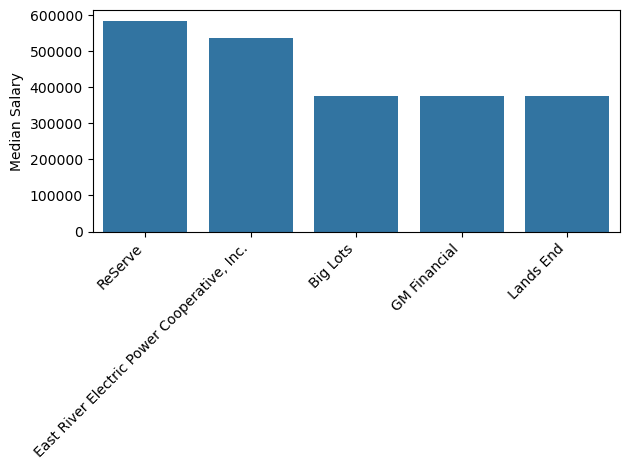

In [25]:
df_filtered = df[(df['job_country'] == 'United States') &
                 (df['job_title_short'] == 'Data Scientist')].dropna(subset = ['salary_year_avg'])

df_filtered_group = (
    df_filtered.groupby('company_name')['salary_year_avg'].median()
    .reset_index(name = 'median_salary')
    .sort_values(by = 'median_salary', ascending = False)
    .head()
)
sns.barplot(data = df_filtered_group, x = 'company_name', y = 'median_salary')
plt.xlabel('')
plt.ylabel('Median Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



---

## 🟨 Data Scientist Salary Histogram (2.20.2)

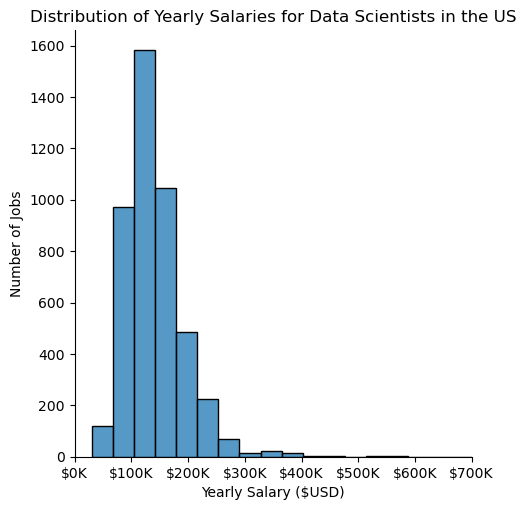

In [37]:
df_filtered = (df[(df['job_title_short'] == 'Data Scientist') &
                 (df['job_country'] == 'United States')]
                 .dropna(subset = ['salary_year_avg'])
)
sns.displot(data = df_filtered['salary_year_avg'], bins = 25, kde = False)
plt.title('Distribution of Yearly Salaries for Data Scientists in the US')
plt.ylabel('Number of Jobs')
plt.xlabel('Yearly Salary ($USD)')
plt.xlim(0,700000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

---

## 🟨 Data Roles Salary Box Plot (2.20.3)

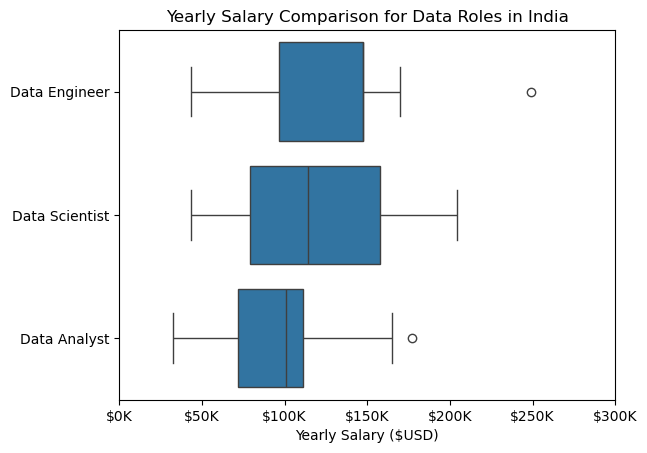

In [47]:
# Code Needed
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_filtered = df[(df['job_country'] == 'India')
                 & df['job_title_short'].isin(job_titles)]
df_filtered = df_filtered.dropna(subset = ['salary_year_avg']).reset_index()


sns.boxplot(data = df_filtered, x = 'salary_year_avg',y = 'job_title_short')
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.xlim(0,300000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.show()

---

## 🟨 Salary Distribution for United States (2.20.4)

(0.0, 500000.0)

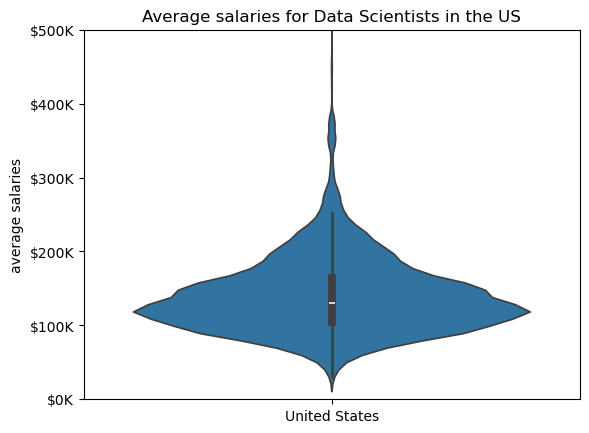

In [54]:
df_filtered = (df[(df['job_title_short'] == 'Data Scientist') &
                 (df['job_country'] == 'United States')]
                 .dropna(subset = ['salary_year_avg'])
)
sns.violinplot(data = df_filtered, x = 'job_country', y = 'salary_year_avg')
plt.title('Average salaries for Data Scientists in the US')
plt.xlabel('')
plt.ylabel('average salaries')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.ylim(0,500000)

---